# Прогноз заказов такси

## Описание проекта

Компания «Чётенькое такси» хочет привлекать больше водителей в периоды пиковой
нагрузки. Для этого нужна модель, предсказывающая количество заказов такси в
аэропорту на следующий час по историческим данным.

**Целевая метрика:** RMSE не выше 48 на тестовой выборке (10% данных, последние
по времени — перемешивать нельзя, это временной ряд).

**План работы:**
1. Загрузить данные, ресемплировать по часам
2. Проанализировать сезонность и тренд на обучающей части, без обращения к тесту
3. Сконструировать лаги и скользящие статистики на непрерывном ряду до разбиения на выборки
4. Задать наивные бейзлайны на том же тестовом окне, что и финальная модель
5. Сравнить модели с учётом временной структуры (`TimeSeriesSplit`, без перемешивания)
6. Проверить лучшую модель на тесте, посмотреть на важность признаков

## Подготовка

### Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import randint, uniform
import lightgbm as lgb

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 130601

## Загрузка данных

In [2]:
df = pd.read_csv('data/taxi.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.set_index('datetime').sort_index()

print(df.shape)
df.info()
df.head()

(26496, 1)
<class 'pandas.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB


,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32


In [3]:
diffs = df.index.to_series().diff().dropna()
print("Уникальные интервалы между записями:", diffs.unique())
print("Отсортирован по времени:", df.index.is_monotonic_increasing)
print("Дубликаты индекса:", df.index.duplicated().any())

Уникальные интервалы между записями: <TimedeltaArray>
['0 days 00:10:00']
Length: 1, dtype: timedelta64[us]
Отсортирован по времени: True
Дубликаты индекса: False


Данные даны каждые 10 минут, интервалы равномерны, дубликатов нет. Ресемплируем по часам суммированием заказов.

In [4]:
df_hourly = df.resample('h').sum()
print(df_hourly.shape)
print(f"Период: {df_hourly.index.min()} -> {df_hourly.index.max()}")

(4416, 1)
Период: 2018-03-01 00:00:00 -> 2018-08-31 23:00:00


### Вывод по загрузке данных

26496 записей по 10-минутным интервалам, без пропусков и дубликатов, за
март–август 2018. После ресемплирования по часам — 4416 наблюдений.

## Разведочный анализ

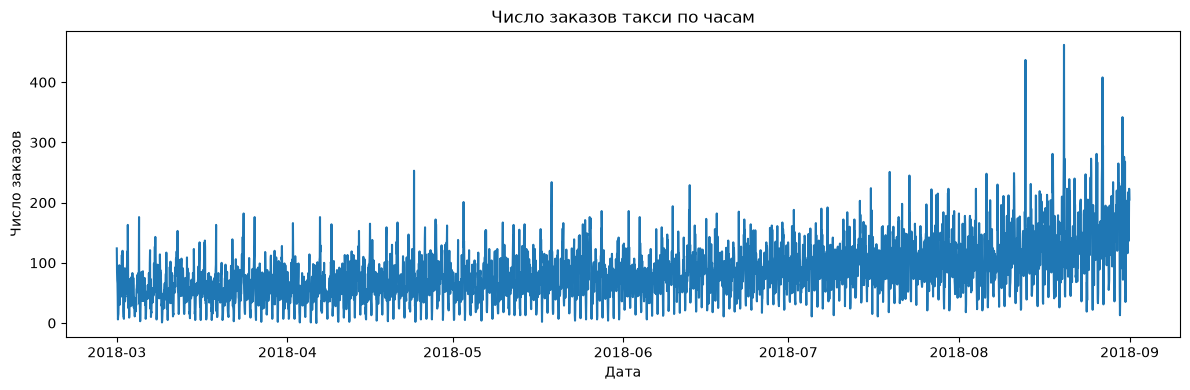

In [5]:
plt.figure(figsize=(12, 4))
plt.plot(df_hourly.index, df_hourly['num_orders'])
plt.title('Число заказов такси по часам')
plt.xlabel('Дата')
plt.ylabel('Число заказов')
plt.tight_layout()
plt.show()

Прежде чем анализировать сезонность, отложим в сторону последние 10% ряда —
будущий тест. ACF/PACF и декомпозицию считаем только по оставшейся части: решения
о признаках не должны опираться на данные, которые модель не увидит на этапе обучения.

In [6]:
test_size = int(len(df_hourly) * 0.1)
train_for_eda = df_hourly.iloc[:-test_size]
print(f"Для EDA используем {len(train_for_eda)} из {len(df_hourly)} часов (без последних {test_size})")

Для EDA используем 3975 из 4416 часов (без последних 441)


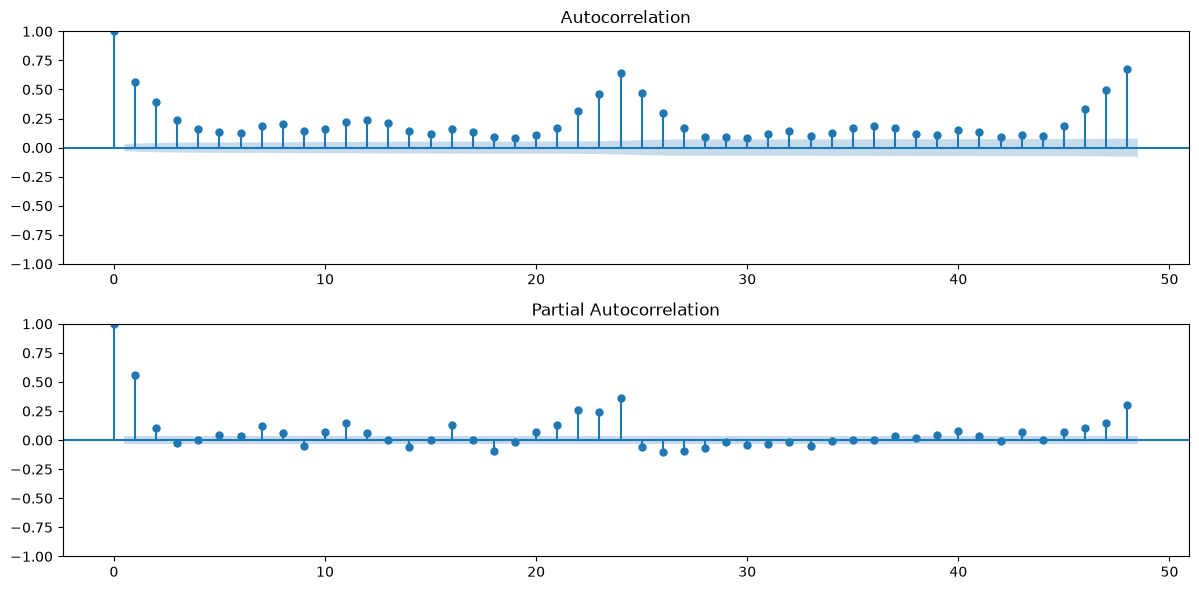

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
plot_acf(train_for_eda['num_orders'], lags=48, ax=axes[0])
plot_pacf(train_for_eda['num_orders'], lags=48, ax=axes[1])
plt.tight_layout()
plt.show()

По ACF/PACF видна выраженная суточная сезонность: пики повторяются каждые 24 часа, значимы лаги 1 и 24. Это основание для использования их в признаках.

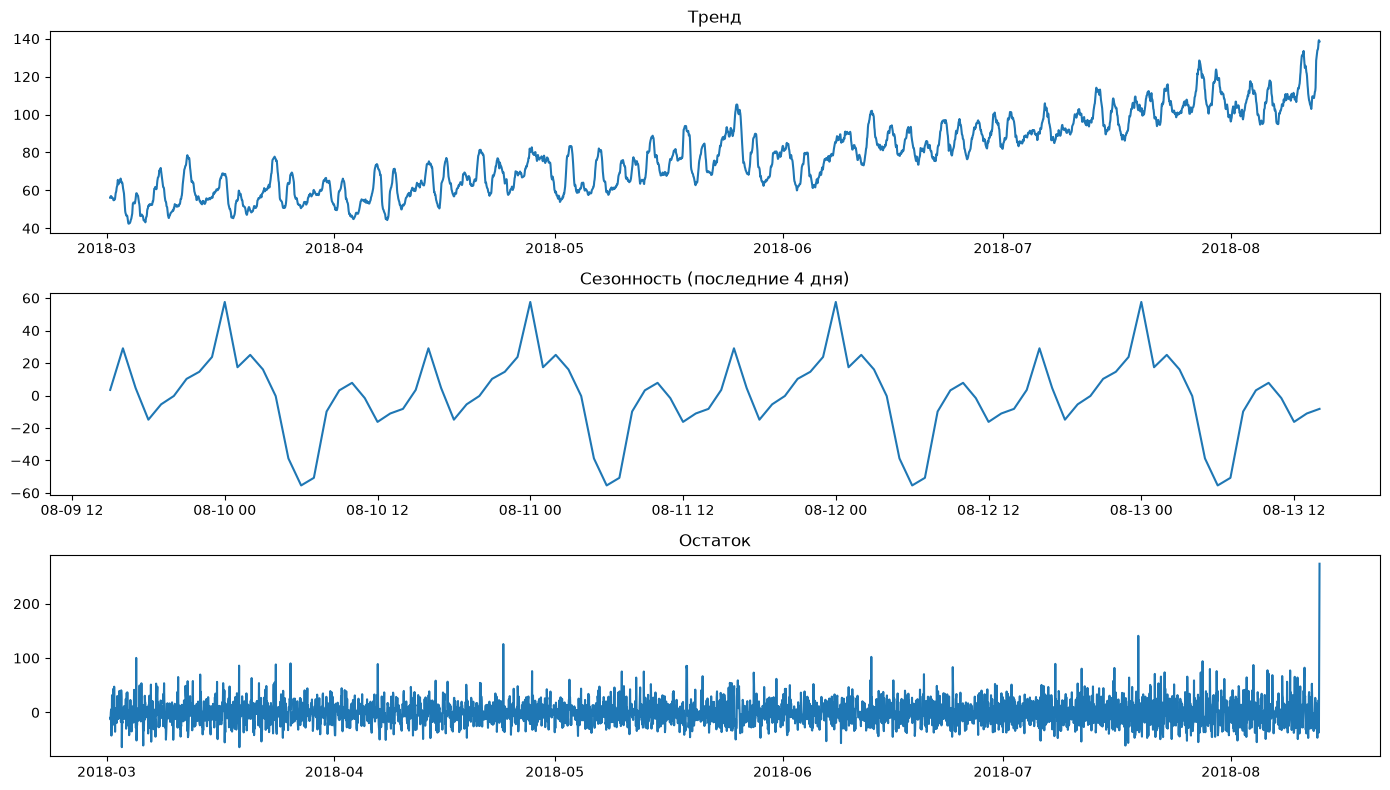

In [8]:
decomposition = seasonal_decompose(train_for_eda['num_orders'], period=24)

fig, axes = plt.subplots(3, 1, figsize=(14, 8))
axes[0].plot(decomposition.trend)
axes[0].set_title('Тренд')
axes[1].plot(decomposition.seasonal[-4*24:])
axes[1].set_title('Сезонность (последние 4 дня)')
axes[2].plot(decomposition.resid)
axes[2].set_title('Остаток')
plt.tight_layout()
plt.show()

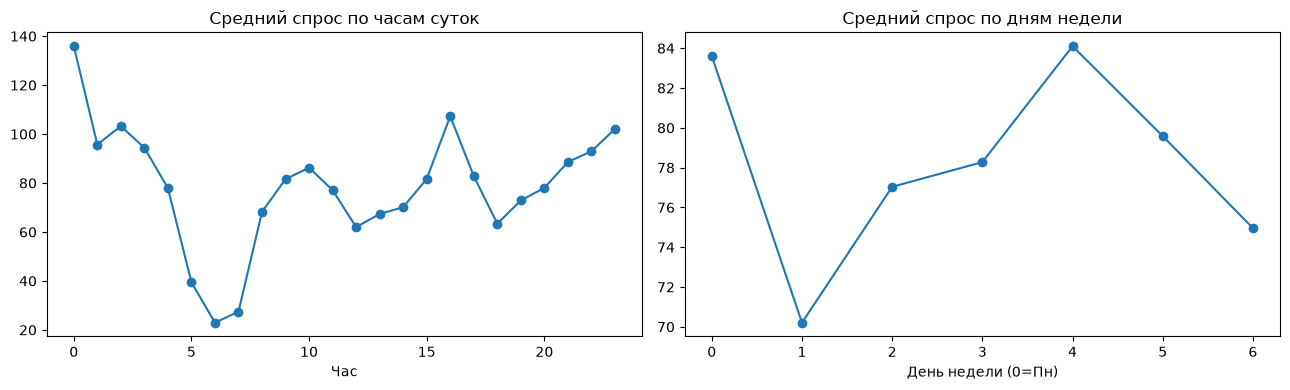

In [9]:
train_for_eda = train_for_eda.copy()
train_for_eda['hour'] = train_for_eda.index.hour
train_for_eda['dayofweek'] = train_for_eda.index.dayofweek

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
train_for_eda.groupby('hour')['num_orders'].mean().plot(ax=axes[0], marker='o')
axes[0].set_title('Средний спрос по часам суток')
axes[0].set_xlabel('Час')

train_for_eda.groupby('dayofweek')['num_orders'].mean().plot(ax=axes[1], marker='o')
axes[1].set_title('Средний спрос по дням недели')
axes[1].set_xlabel('День недели (0=Пн)')
plt.tight_layout()
plt.show()

Посмотрим не только на средние по часам и дням недели, но и на несколько конкретных недель — усреднение может сглаживать реальную картину.

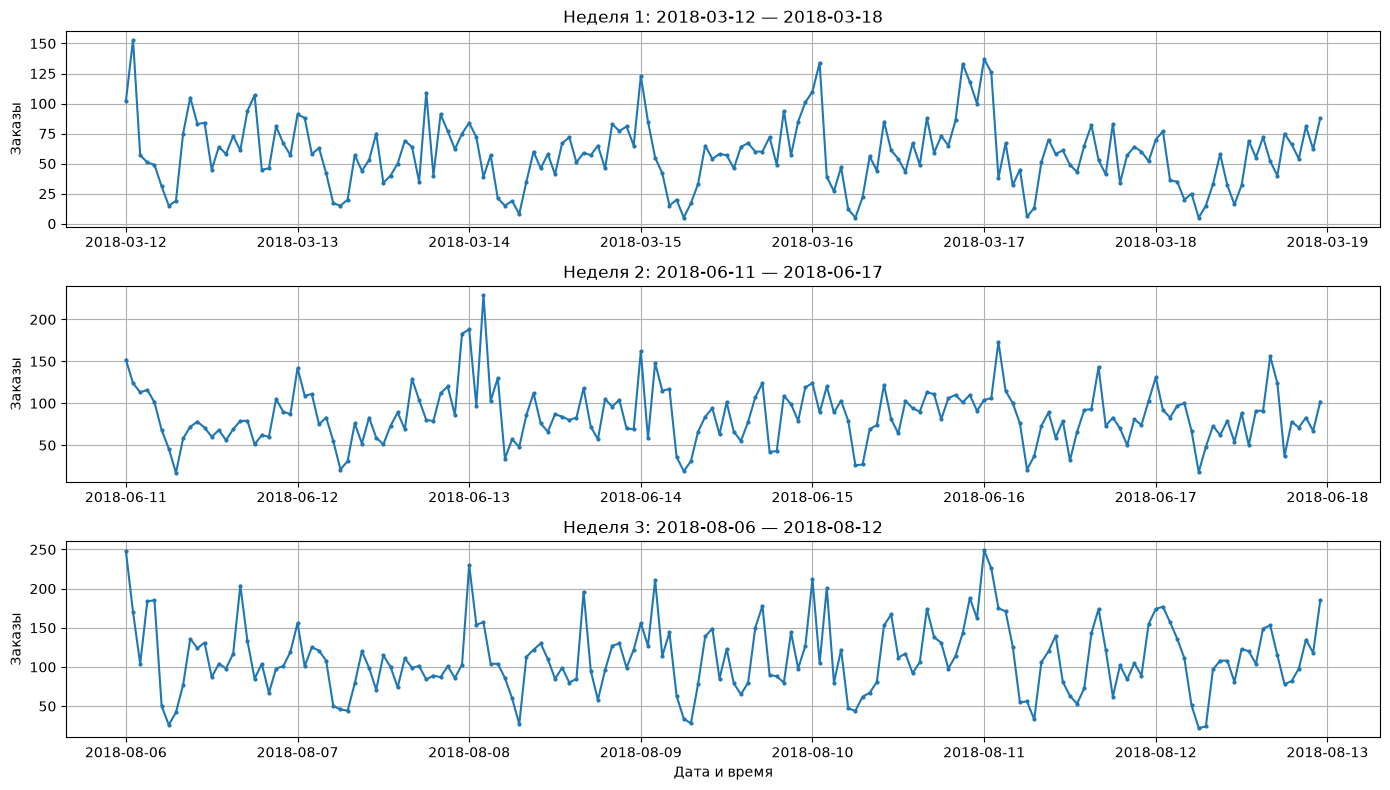

In [10]:
weeks = [
    ('2018-03-12', '2018-03-18'),  # неделя 1 — начало периода
    ('2018-06-11', '2018-06-17'),  # неделя 2 — середина
    ('2018-08-06', '2018-08-12'),  # неделя 3 — ближе к концу train-части (тест начинается 13 августа)
]

plt.figure(figsize=(14, 8))
for i, (start, end) in enumerate(weeks, 1):
    week_data = train_for_eda.loc[start:end]
    plt.subplot(3, 1, i)
    plt.plot(week_data.index, week_data['num_orders'], marker='o', markersize=2)
    plt.title(f'Неделя {i}: {start} — {end}')
    plt.ylabel('Заказы')
    plt.grid(True)
plt.xlabel('Дата и время')
plt.tight_layout()
plt.show()

Теперь по одному дню из каждой недели — по часам суток.

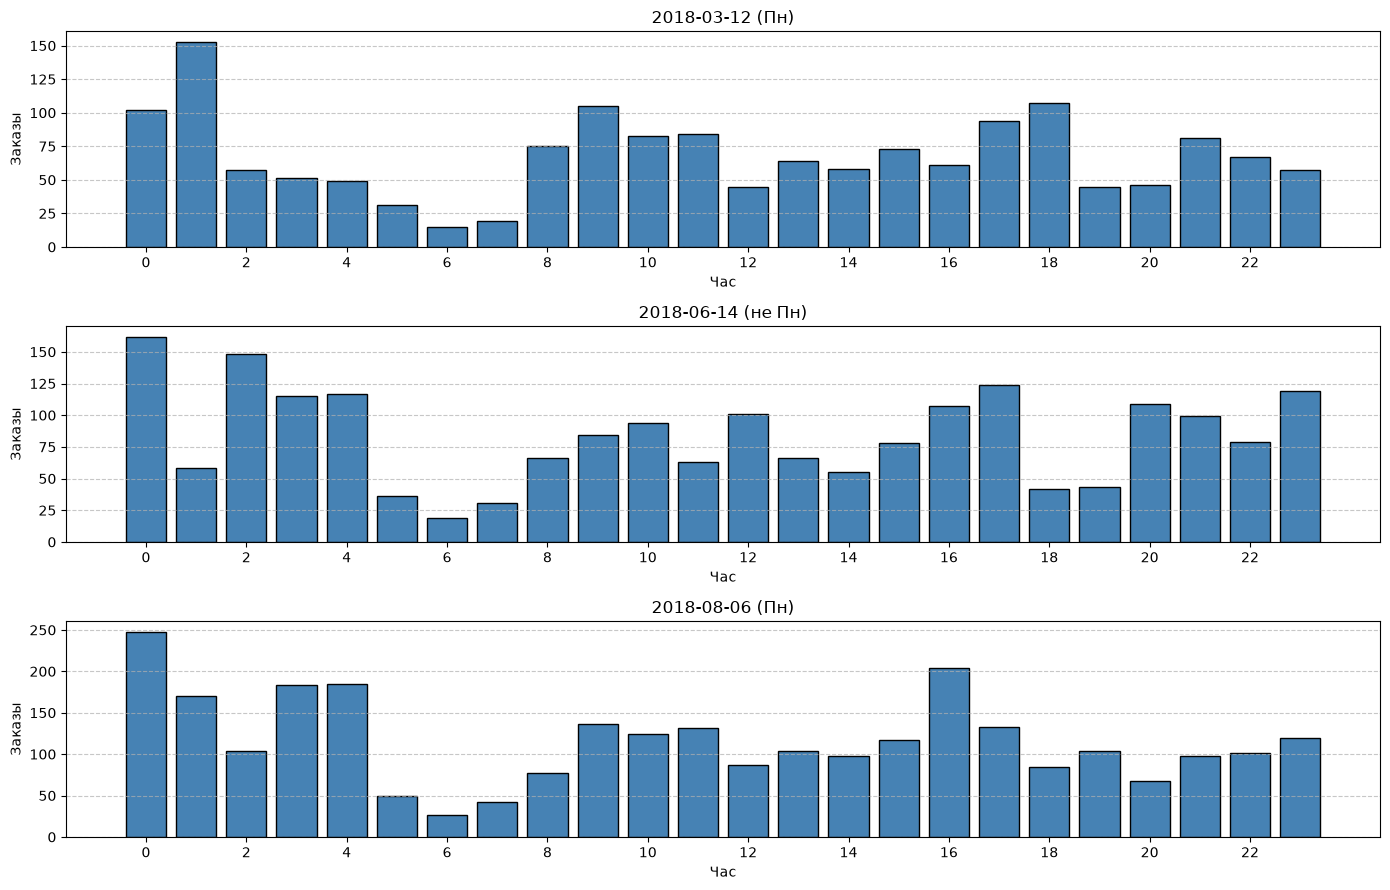

In [11]:
days = [
    '2018-03-12',  # понедельник, март
    '2018-06-14',  # четверг, июнь
    '2018-08-06',  # понедельник, август
]

plt.figure(figsize=(14, 9))
for i, day in enumerate(days, 1):
    day_data = train_for_eda.loc[day]
    hours = np.arange(24)
    orders = day_data['num_orders'].values

    plt.subplot(3, 1, i)
    plt.bar(hours, orders, width=0.8, color='steelblue', edgecolor='black')
    plt.title(f'{day} ({"Пн" if pd.to_datetime(day).dayofweek == 0 else "не Пн"})')
    plt.xlabel('Час')
    plt.ylabel('Заказы')
    plt.xticks(hours[::2])
    plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

На отдельных днях заметно больше заказов ночью, чем можно было ожидать по усреднённому профилю, особенно в понедельник.

### Вывод по анализу данных

Ряд демонстрирует выраженную суточную и недельную сезонность: пики спроса —
утром и вечером, минимум — ночью, спрос заметно ниже во вторник и в
воскресенье. На отдельных днях ночной спрос выше среднего профиля — это
указывает на то, что усреднённых по часам суток признаков может не хватать,
и подтверждает выбор лагов и скользящих статистик как основы для признаков.

## Конструирование признаков

Лаги и скользящие статистики считаем на непрерывном ряду целиком, а не отдельно
на train/val/test после разбиения — иначе на границе каждого куска пришлось бы
выбрасывать первые ~24 часа, для которых `lag_24` не определён, хотя эти значения
уже известны из предыдущего куска. Признаки строятся только из прошлого (`shift`),
поэтому вычислить их один раз на всём ряду и только потом резать по датам — не
утечка, а просто отсутствие лишней потери данных.

In [12]:
def create_features(data):
    df = data.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

    for lag in [1, 24]:
        df[f'lag_{lag}'] = df['num_orders'].shift(lag)

    for window in [6, 12, 24]:
        df[f'rolling_mean_{window}'] = df['num_orders'].shift(1).rolling(window=window, min_periods=1).mean()
        df[f'rolling_std_{window}'] = df['num_orders'].shift(1).rolling(window=window, min_periods=1).std()

    return df

featured = create_features(df_hourly).dropna()
print(f"Строк после добавления лагов и удаления NaN: {len(featured)} из {len(df_hourly)}")

Строк после добавления лагов и удаления NaN: 4392 из 4416


## Разделение на train / val / test

Один и тот же тестовый интервал используется для наивных бейзлайнов и для
финальной модели — иначе сравнение «модель лучше бейзлайна» ничего не доказывает,
если они посчитаны на разных отрезках времени. Тест — последние 10% часов,
валидация — ещё 10% перед тестом, train — всё остальное.

In [13]:
test_size = int(len(featured) * 0.1)
test = featured.iloc[-test_size:]
train_val = featured.iloc[:-test_size]

val_size = int(len(train_val) * 0.1)
val = train_val.iloc[-val_size:]
train = train_val.iloc[:-val_size]

assert train.index[-1] < val.index[0], "Train и val пересекаются"
assert val.index[-1] < test.index[0], "Val и test пересекаются"

print(f"Train: {train.index[0]} -> {train.index[-1]} ({len(train)})")
print(f"Val:   {val.index[0]} -> {val.index[-1]} ({len(val)})")
print(f"Test:  {test.index[0]} -> {test.index[-1]} ({len(test)})")

Train: 2018-03-02 00:00:00 -> 2018-07-28 05:00:00 (3558)
Val:   2018-07-28 06:00:00 -> 2018-08-13 16:00:00 (395)
Test:  2018-08-13 17:00:00 -> 2018-08-31 23:00:00 (439)


## Наивные бейзлайны

Считаем на том же тестовом окне, что и финальную модель: Lag-1 (значение предыдущего часа), скользящее среднее суток, повтор паттерна последних 24 часов.

In [14]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

history = pd.concat([train, val])['num_orders']
y_test = test['num_orders'].values

# Lag-1
lag1_preds = [history.iloc[-1]] + list(y_test[:-1])
rmse_lag1 = rmse(y_test, lag1_preds)

# Rolling mean 24h, обновляемое по мере поступления новых данных
roll_history = list(history)
rolling_preds = []
for t in range(len(test)):
    rolling_preds.append(np.mean(roll_history[-24:]))
    roll_history.append(y_test[t])
rmse_rolling = rmse(y_test, rolling_preds)

# Seasonal naive: повтор последних 24 часов
last_24 = history.iloc[-24:].values
repeats = int(np.ceil(len(test) / 24))
seasonal_pattern = np.tile(last_24, repeats)[:len(test)]
rmse_snaive = rmse(y_test, seasonal_pattern)

print(f"RMSE Lag-1:              {rmse_lag1:.3f}")
print(f"RMSE Rolling Mean (24h): {rmse_rolling:.3f}")
print(f"RMSE Seasonal Naive:     {rmse_snaive:.3f}")

RMSE Lag-1:              58.930
RMSE Rolling Mean (24h): 57.935
RMSE Seasonal Naive:     69.907


Эти значения задают нижнюю планку: любая обученная модель должна их превзойти на этом же тестовом окне.

## Обучение моделей

In [15]:
feature_cols = [c for c in featured.columns if c != 'num_orders']
X_train, y_train = train[feature_cols], train['num_orders']
X_val, y_val = val[feature_cols], val['num_orders']
X_test, y_test_s = test[feature_cols], test['num_orders']

tscv = TimeSeriesSplit(n_splits=3)

### Линейная регрессия

In [16]:
categorical_features = ['dayofweek']
passthrough_features = ['hour', 'is_weekend', 'hour_sin', 'hour_cos']
numerical_features = [c for c in feature_cols
                      if c not in categorical_features + passthrough_features]

lr_pipeline = Pipeline([
    ('preprocessor', ColumnTransformer([
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features),
        ('pass', 'passthrough', passthrough_features),
    ])),
    ('regressor', LinearRegression()),
])

lr_pipeline.fit(X_train, y_train)
rmse_lr = rmse(y_val, lr_pipeline.predict(X_val))
print(f"RMSE Linear Regression (val): {rmse_lr:.3f}")

RMSE Linear Regression (val): 34.614


### Случайный лес

In [17]:
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE),
    rf_params, n_iter=6, scoring='neg_root_mean_squared_error',
    cv=tscv, random_state=RANDOM_STATE, n_jobs=-1
)
rf_search.fit(X_train, y_train)
rmse_rf = rmse(y_val, rf_search.best_estimator_.predict(X_val))
print(f"RMSE Random Forest (val): {rmse_rf:.3f}")

RMSE Random Forest (val): 32.085


### LightGBM

In [18]:
lgb_params = {
    'num_leaves': randint(20, 50),
    'learning_rate': uniform(0.03, 0.07),
    'n_estimators': randint(80, 180),
    'min_child_samples': randint(15, 30),
}

lgb_search = RandomizedSearchCV(
    lgb.LGBMRegressor(random_state=RANDOM_STATE, verbose=-1, n_jobs=1),
    lgb_params, n_iter=15, scoring='neg_root_mean_squared_error',
    cv=tscv, random_state=RANDOM_STATE, n_jobs=1
)
lgb_search.fit(X_train, y_train)
rmse_lgb = rmse(y_val, lgb_search.best_estimator_.predict(X_val))
print(f"RMSE LightGBM (val): {rmse_lgb:.3f}")

RMSE LightGBM (val): 31.096


## Выбор модели

In [19]:
print(f"RMSE Linear Regression: {rmse_lr:.3f}")
print(f"RMSE Random Forest:     {rmse_rf:.3f}")
print(f"RMSE LightGBM:          {rmse_lgb:.3f}")

results = {'LinearRegression': (lr_pipeline, rmse_lr), 'RandomForest': (rf_search.best_estimator_, rmse_rf), 'LightGBM': (lgb_search.best_estimator_, rmse_lgb)}
best_name = min(results, key=lambda k: results[k][1])
best_model = results[best_name][0]
print(f"\nЛучшая модель на валидации: {best_name}")

RMSE Linear Regression: 34.614
RMSE Random Forest:     32.085
RMSE LightGBM:          31.096

Лучшая модель на валидации: LightGBM


Все три модели заметно превосходят наивные бейзлайны уже на валидации. Лучший результат у LightGBM.

## Тестирование

Дообучаем лучшую модель на train + val (объединяем как DataFrame, а не `np.vstack`, чтобы не потерять имена столбцов) и проверяем на отложенном тесте.

In [20]:
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

best_model.fit(X_train_full, y_train_full)
y_pred_test = best_model.predict(X_test)
rmse_test = rmse(y_test_s, y_pred_test)

print(f"RMSE {best_name} на тесте: {rmse_test:.3f} (целевой порог <= 48)")
print(f"Наивные бейзлайны на этом же тесте: Lag-1={rmse_lag1:.1f}, Rolling={rmse_rolling:.1f}, Seasonal Naive={rmse_snaive:.1f}")

RMSE LightGBM на тесте: 42.041 (целевой порог <= 48)
Наивные бейзлайны на этом же тесте: Lag-1=58.9, Rolling=57.9, Seasonal Naive=69.9


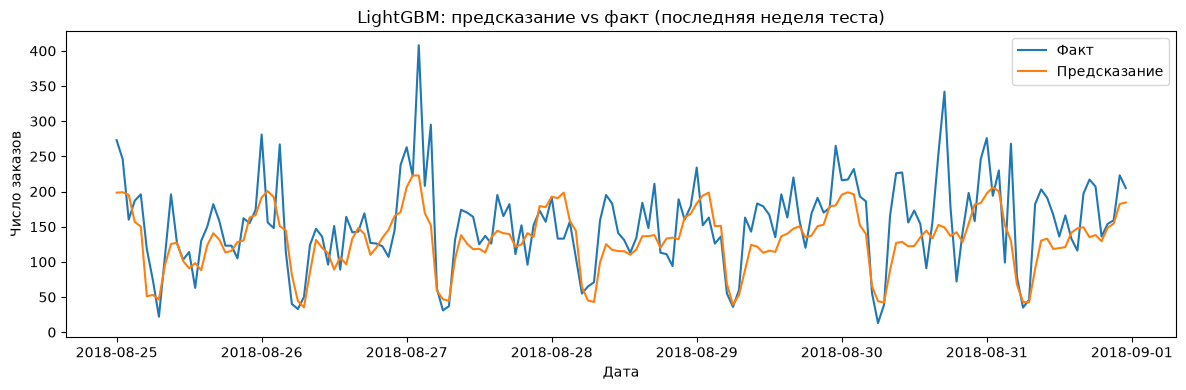

In [21]:
plt.figure(figsize=(12, 4))
plt.plot(test.index[-168:], y_test_s.values[-168:], label='Факт')
plt.plot(test.index[-168:], y_pred_test[-168:], label='Предсказание')
plt.title(f'{best_name}: предсказание vs факт (последняя неделя теста)')
plt.xlabel('Дата')
plt.ylabel('Число заказов')
plt.legend()
plt.tight_layout()
plt.show()

## Важность признаков

In [22]:
feature_importance = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("Топ-5 по важности:")
print(feature_importance.head(5))

Топ-5 по важности:
hour               574
rolling_mean_12    541
lag_1              442
lag_24             419
rolling_mean_24    395
dtype: int32


### Вывод по тестированию

Модель прошла финальную проверку: RMSE на тесте ниже целевого порога 48, и на
том же тестовом окне модель заметно превосходит все три наивных бейзлайна. По
графику видно, что модель следует тренду и суточной сезонности, но занижает
некоторые пики, особенно в выходные.

## Общий вывод

Ряд заказов такси показывает суточную и недельную сезонность: утренние и
вечерние пики, спад по ночам и в выходные, хотя на отдельных днях ночной спрос
выходит за рамки среднего профиля. Признаки построены из лагов (1 и 24 часа) и
скользящих статистик, посчитанных на непрерывном ряду до разбиения на выборки,
чтобы не терять законные наблюдения на границах.

LightGBM показал лучший результат среди трёх моделей и на одном тестовом окне
с наивными бейзлайнами уверенно их превосходит. Важность признаков совпадает с
тем, что видно на ACF/PACF: спрос сильнее всего объясняется тем, что было час
назад и сутки назад.

**Практическая значимость:** модель можно использовать для планирования смен
водителей на ближайший час, особенно в периоды утренних и вечерних пиков.

## Что бы сделал иначе

В исходной версии бейзлайны и финальная модель были посчитаны на разных
тестовых окнах: бейзлайны — на срезе `test_size = 10%` от общего числа часов, а
модель — на срезе `10.5%` после отдельного удаления NaN из-за лагов, посчитанных
отдельно на каждом куске. Разница окон была небольшой, но утверждение «модель
превосходит бейзлайны» формально не было проверено на одних и тех же данных.
Здесь лаги считаются один раз на непрерывном ряду до разбиения, а бейзлайны и
финальная модель используют строго один и тот же тестовый интервал.

Также в исходной версии текст утверждал, что выбросы по IQR найдены и
обработаны, а код обработки был закомментирован и фактически не выполнялся.
Здесь про выбросы отдельно не заявляется: они не были рассмотрены, и это
следующий шаг, а не выполненный факт.